# TerraFoma — Biomass Estimation & Multi-Model Benchmark



| TerraFoma Architechture | Implementation |
|---|---|
| Multi-sensor fusion (S1, S2, GEDI, terrain) | Simulated feature dataset matching GEE pipeline |
| Multi-model benchmark (RF, XGBoost, SVR, CNN) | Section 4 — all four trained and compared |
| Spatial block cross-validation | 0.5° grid blocks, GroupKFold to prevent autocorrelation |
| log1p target transform | Applied throughout; inverted for reporting |
| Quantified uncertainty | RF prediction intervals + CV RMSE-based bounds |
| Feature importance / explainability | SHAP + permutation importance |

**Target variable:** Above-Ground Biomass Density (AGBD) in tonnes/ha  
**Study region:** Rwanda (entire country)

In [39]:
# ── Imports (Windows-safe — shim Unix terminal modules used by earthengine-api) ─
import warnings
warnings.filterwarnings("ignore")

import sys
import types
import io

if sys.platform.startswith("win"):
    if "fcntl" not in sys.modules:
        fcntl_stub = types.ModuleType("fcntl")

        def ioctl(*args, **kwargs):
            raise OSError("fcntl is not available on Windows")

        fcntl_stub.ioctl = ioctl
        sys.modules["fcntl"] = fcntl_stub

    if "termios" not in sys.modules:
        termios_stub = types.ModuleType("termios")
        termios_stub.TIOCGWINSZ = 0
        sys.modules["termios"] = termios_stub

    if "curses" not in sys.modules:
        curses_stub = types.ModuleType("curses")

        def _return_zero(*args, **kwargs):
            return 0

        def _return_empty(*args, **kwargs):
            return b""

        curses_stub.setupterm = _return_zero
        curses_stub.tigetnum = _return_zero
        curses_stub.tigetstr = _return_empty
        curses_stub.tparm = _return_empty
        curses_stub.error = RuntimeError
        sys.modules["curses"] = curses_stub

    if "StringIO" not in sys.modules:
        stringio_stub = types.ModuleType("StringIO")
        stringio_stub.StringIO = io.StringIO
        sys.modules["StringIO"] = stringio_stub

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

import ee


# Sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

# XGBoost (optional)
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("⚠  xgboost not installed — will use GradientBoostingRegressor as fallback")
    from sklearn.ensemble import GradientBoostingRegressor

# PyTorch (optional)
try:
    import torch
    import torch.nn as nn
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    print("⚠  PyTorch not installed — CNN model will be skipped")

import joblib

np.random.seed(42)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (12, 5)})

print("✅  Imports complete")
print(f"   XGBoost  : {'available' if XGB_AVAILABLE else 'fallback to sklearn GBR'}")
print(f"   PyTorch  : {'available' if TORCH_AVAILABLE else 'skipped'}")

✅  Imports complete
   XGBoost  : available
   PyTorch  : available


## 1. Dataset — Multi-Sensor Real Data from Google Earth Engine

**Real data pipeline** (falls back to simulated data if GEE authentication fails):

This notebook fetches 2,000 samples from Google Earth Engine matching the research proposal architecture (§3.3.1).

**Sensors integrated:**
- **Sentinel-2** — 10 spectral bands + 5 vegetation indices (NDVI, EVI, SAVI, NDMI, NBR)
- **Sentinel-1 SAR** — VV and VH backscatter (dB), VH–VV difference (C-band, Copernicus)
- **GEDI LiDAR** — canopy height percentiles (rh50, rh75, rh98) and cover fraction (LARSE products)
- **Terrain (SRTM)** — elevation (m) and slope (degrees)

**Label:** `agbd_tonnes_per_ha` — above-ground biomass density from GEDI L4A
**Study region:** Rwanda (entire country)
**Spatial metadata:** `lat`, `lon` — used for spatial block cross-validation to prevent autocorrelation leakage

In [ ]:
# ── 0. Install earthengine-api if missing ─────────────────────────────────────
import subprocess, sys
try:
    import ee
except ModuleNotFoundError:
    print("Installing earthengine-api...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "earthengine-api", "--quiet"])
    import ee
    print("✅ earthengine-api installed")

# ── 1. Authenticate & Initialise GEE with TerraFoma project ───────────────────
GEE_PROJECT = "nimble-button-433709-e7"

print(f"Initializing Google Earth Engine (project: {GEE_PROJECT})...")
EE_AVAILABLE = False

try:
    ee.Initialize(project=GEE_PROJECT)
    print(f"✅ Earth Engine authenticated — project: {GEE_PROJECT}")
    EE_AVAILABLE = True
except Exception as e:
    print(f"⚠  Earth Engine is not authenticated yet: {e}")
    print("")
    print("Windows auth steps:")
    print("  1) Open a terminal in this project venv")
    print("  2) Run: earthengine authenticate")
    print("  3) Complete the browser login and approve access")
    print("  4) Restart the notebook kernel and rerun this cell")
    print("")
    print("Optional service account path:")
    print("  Set GOOGLE_APPLICATION_CREDENTIALS=path/to/service-account.json")
    print("  Then rerun this cell")
    EE_AVAILABLE = False

if EE_AVAILABLE:
    # ── 2. Define Rwanda study area (entire country) ───────────────────────────
    RWANDA_BOUNDS = (
        ee.FeatureCollection("FAO/GAUL/2015/level0")
        .filter(ee.Filter.eq("ADM0_NAME", "Rwanda"))
        .geometry()
    )

    print("\n" + "="*60)
    print("TerraFoma — Real Data Pipeline (Google Earth Engine)")
    print("="*60)
    print("Region : Entire Rwanda")
    print("Bounds : Rwanda national boundary (FAO/GAUL 2015 level 0)")
    print("Dataset: COPERNICUS/S2_SR_HARMONIZED")
    print("Date   : 2023-01-01 to 2024-12-31")

    # ── 3. Fetch Sentinel-2 imagery ───────────────────────────────────────────
    print("\n[1/5] Fetching Sentinel-2 (COPERNICUS/S2_SR_HARMONIZED)...")
    S2_COLLECTION = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(RWANDA_BOUNDS)
        .filterDate("2023-01-01", "2024-12-31")
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    )
    n_s2 = S2_COLLECTION.size().getInfo()
    print(f"   Found {n_s2} cloud-free Sentinel-2 scenes")

    def add_s2_indices(image):
        ndvi = image.normalizedDifference(["B8", "B4"]).rename("ndvi")
        evi = image.expression(
            "2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))",
            {"NIR": image.select("B8"), "RED": image.select("B4"), "BLUE": image.select("B2")}
        ).rename("evi")
        savi = image.expression(
            "((NIR - RED) / (NIR + RED + 0.5)) * 1.5",
            {"NIR": image.select("B8"), "RED": image.select("B4")}
        ).rename("savi")
        ndmi = image.normalizedDifference(["B8", "B11"]).rename("ndmi")
        nbr  = image.normalizedDifference(["B8", "B12"]).rename("nbr")
        return image.addBands([ndvi, evi, savi, ndmi, nbr])

    s2_composite = S2_COLLECTION.map(add_s2_indices).median().clip(RWANDA_BOUNDS)
    print("   ✅ Sentinel-2 composite + indices (NDVI, EVI, SAVI, NDMI, NBR) ready")

    # ── 4. Fetch Sentinel-1 SAR data ──────────────────────────────────────────
    print("\n[2/5] Fetching Sentinel-1 SAR backscatter (COPERNICUS/S1_GRD)...")
    S1_COLLECTION = (
        ee.ImageCollection("COPERNICUS/S1_GRD")
        .filterBounds(RWANDA_BOUNDS)
        .filterDate("2023-01-01", "2024-12-31")
        .filter(ee.Filter.eq("instrumentMode", "IW"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
        .select(["VV", "VH"])
    )
    n_s1 = S1_COLLECTION.size().getInfo()
    print(f"   Found {n_s1} Sentinel-1 images")
    s1_composite = S1_COLLECTION.median().clip(RWANDA_BOUNDS)
    s1_composite = s1_composite.addBands(
        s1_composite.select("VH").subtract(s1_composite.select("VV")).rename("vh_vv_diff")
    )
    print("   ✅ SAR composite ready (VV, VH, VH-VV)")

    # ── 5. Fetch GEDI L4A biomass + L2A canopy height ─────────────────────────
    print("\n[3/5] Fetching GEDI L4A biomass + L2A canopy height...")
    gedi_agbd = (
        ee.ImageCollection("LARSE/GEDI/GEDI04_A_002_MONTHLY")
        .filterBounds(RWANDA_BOUNDS)
        .select(["agbd"])
        .mean()
        .rename("agbd_tonnes_per_ha")
        .clip(RWANDA_BOUNDS)
    )
    gedi_height = (
        ee.ImageCollection("LARSE/GEDI/GEDI02_A_002_MONTHLY")
        .filterBounds(RWANDA_BOUNDS)
        .select(["rh50", "rh75", "rh98", "modis_treecover"])
        .mean()
        .select(["rh50", "rh75", "rh98", "modis_treecover"], ["rh50", "rh75", "rh98", "cover"])
        .clip(RWANDA_BOUNDS)
    )
    print("   ✅ GEDI biomass (agbd) + canopy metrics (rh50/75/98, cover proxy) ready")

    # ── 6. Fetch SRTM terrain ──────────────────────────────────────────────────
    print("\n[4/5] Fetching SRTM terrain (USGS/SRTMGL1_003)...")
    dem   = ee.Image("USGS/SRTMGL1_003").select("elevation").clip(RWANDA_BOUNDS)
    slope = ee.Terrain.slope(dem).rename("slope")
    print("   ✅ Terrain (elevation, slope) ready")

    # ── 7. Merge all bands into one multi-band image ───────────────────────────
    print("\n[5/5] Merging sensor layers...")
    all_features = (
        s2_composite
        .select(["B2", "B3", "B4", "B8", "B11", "B12",
                 "ndvi", "evi", "savi", "ndmi", "nbr"])
        .addBands(s1_composite.select(["VV", "VH", "vh_vv_diff"]))
        .addBands(gedi_agbd)
        .addBands(gedi_height)
        .addBands(dem)
        .addBands(slope)
    )

    FEATURE_LIST = [
        "B2", "B3", "B4", "B8", "B11", "B12",
        "ndvi", "evi", "savi", "ndmi", "nbr",
        "VV", "VH", "vh_vv_diff",
        "agbd_tonnes_per_ha",
        "rh50", "rh75", "rh98", "cover",
        "elevation", "slope",
    ]
    all_features = all_features.select(FEATURE_LIST)
    print(f"   Total bands merged: {len(FEATURE_LIST)}")

    # ── 8. Sample 2,000 random training points ────────────────────────────────
    print("\n⏳ Sampling 2,000 training points from Rwanda study area...")
    print("   (May take 2-3 minutes on first run — GEE compute)")
    sample_image = all_features.addBands(ee.Image.pixelLonLat())
    samples = (
        sample_image
        .sample(region=RWANDA_BOUNDS, scale=30, numPixels=2000, seed=42, geometries=False, tileScale=4)
        .getInfo()
    )
    n_samples = len(samples["features"])
    print(f"✅ Sampled {n_samples} points from GEE")

    # ── 9. GEE FeatureCollection → pandas DataFrame ───────────────────────────
    rows = []
    for feat in samples["features"]:
        props = feat["properties"]
        rows.append({"lon": props.pop("longitude"), "lat": props.pop("latitude"), **props})

    df = (
        pd.DataFrame(rows)
        .rename(columns={
            "B2": "blue", "B3": "green", "B4": "red",
            "B8": "nir", "B11": "swir1", "B12": "swir2",
            "VV": "vv",  "VH": "vh",
        })
        .dropna()
        .reset_index(drop=True)
    )

    # Classify land use from NDVI
    def classify_land_use(v):
        if v < 0.35: return "Cropland"
        if v < 0.50: return "Grassland"
        if v < 0.65: return "Agroforestry"
        return "Forest"

    LU_MAP = {"Cropland": 0, "Grassland": 1, "Agroforestry": 2, "Forest": 3}
    df["land_use"]     = df["ndvi"].apply(classify_land_use)
    df["land_use_enc"] = df["land_use"].map(LU_MAP)

    print(f"\n{'='*60}")
    print(" Dataset: Real GEDI + Sentinel-2/1 + SRTM from GEE")
    print(f"{'='*60}")
    print(f" Project  : {GEE_PROJECT}")
    print(f" Samples  : {len(df):,}")
    print(f" S2 scenes: {n_s2}  |  S1 scenes: {n_s1}")
    print(f" AGBD     : {df['agbd_tonnes_per_ha'].min():.1f} – {df['agbd_tonnes_per_ha'].max():.1f} t/ha")
    print(f" Mean±std : {df['agbd_tonnes_per_ha'].mean():.1f} ± {df['agbd_tonnes_per_ha'].std():.1f} t/ha")
    print(f"\n Land use breakdown:")
    print(df["land_use"].value_counts().to_string())
    print(f"{'='*60}\n")

else:
    # ── Fallback: realistic simulated Rwanda data ─────────────────────────────
    print("\n⚠  Using simulated Rwanda dataset (GEE unavailable).")
    print("   To switch to real data: run `earthengine authenticate` then restart kernel.\n")

    N   = 2000
    rng = np.random.default_rng(42)

    lat = rng.uniform(-2.85, -1.05, N)
    lon = rng.uniform(29.5,  30.9,  N)

    land_use_enc  = rng.choice([0, 1, 2, 3, 4], N, p=[0.25, 0.35, 0.20, 0.15, 0.05])
    land_use_names = {0: "Forest", 1: "Agroforestry", 2: "Grassland", 3: "Cropland", 4: "Wetland"}

    elevation = rng.uniform(1350, 2600, N)
    slope     = rng.uniform(1, 30, N)

    ndvi_base = np.array([0.78, 0.62, 0.38, 0.42, 0.55])[land_use_enc]
    ndvi  = np.clip(rng.normal(ndvi_base, 0.10, N), 0.05, 0.95)
    evi   = np.clip(ndvi * rng.uniform(0.55, 0.70, N), 0.02, 0.80)
    savi  = np.clip(ndvi * rng.uniform(0.80, 0.95, N), 0.02, 0.90)
    nir   = np.clip(rng.normal(0.38, 0.10, N) + ndvi * 0.15, 0.05, 0.80)
    red   = np.clip(rng.normal(0.07, 0.03, N), 0.02, 0.25)
    blue  = np.clip(rng.normal(0.05, 0.02, N), 0.01, 0.15)
    green = np.clip(rng.normal(0.08, 0.02, N), 0.02, 0.20)
    swir1 = np.clip(rng.normal(0.18, 0.05, N), 0.04, 0.45)
    swir2 = np.clip(rng.normal(0.10, 0.04, N), 0.02, 0.35)
    ndmi  = (nir - swir1) / (nir + swir1 + 1e-9)
    nbr   = (nir - swir2) / (nir + swir2 + 1e-9)

    vv         = rng.normal(-11.5, 2.5, N) + ndvi * (-2.0)
    vh         = rng.normal(-18.5, 3.0, N) + ndvi * (-3.0)
    vh_vv_diff = vh - vv

    rh98_base = np.array([22.0, 12.0, 4.0, 3.5, 8.0])[land_use_enc]
    rh98  = np.clip(rng.normal(rh98_base, 4.0, N), 0.5, 45.0)
    rh75  = np.clip(rh98 * rng.uniform(0.65, 0.85, N), 0.3, 38.0)
    rh50  = np.clip(rh75 * rng.uniform(0.55, 0.80, N), 0.2, 30.0)
    cover = np.clip(rng.normal(0.60, 0.18, N) + ndvi * 0.30, 0.05, 0.99)

    agbd = np.clip(
        2.5 * rh98**1.15 + ndvi * 120 + vh * (-2.8) + cover * 80 - slope * 0.8
        + rng.normal(0, 18, N),
        2.0, 450.0,
    )

    df = pd.DataFrame({
        "lat": lat, "lon": lon,
        "blue": blue, "green": green, "red": red, "nir": nir,
        "swir1": swir1, "swir2": swir2,
        "ndvi": ndvi, "evi": evi, "savi": savi, "ndmi": ndmi, "nbr": nbr,
        "vv": vv, "vh": vh, "vh_vv_diff": vh_vv_diff,
        "rh50": rh50, "rh75": rh75, "rh98": rh98, "cover": cover,
        "elevation": elevation, "slope": slope,
        "land_use_enc": land_use_enc,
        "land_use": [land_use_names[v] for v in land_use_enc],
        "agbd_tonnes_per_ha": agbd,
    })

    print(f"Simulated dataset : {df.shape}")
    print(f"AGBD range        : {agbd.min():.1f} – {agbd.max():.1f} t/ha")
    print(f"AGBD mean±std     : {agbd.mean():.1f} ± {agbd.std():.1f} t/ha")
    print(f"\nLand-use breakdown:")
    print(df["land_use"].value_counts().to_string())

    df.head()

Initializing Google Earth Engine (project: nimble-button-433709-e7)...
✅ Earth Engine authenticated — project: nimble-button-433709-e7

TerraFoma — Real Data Pipeline (Google Earth Engine)
Region : Entire Rwanda
Bounds : Rwanda national boundary (FAO/GAUL 2015 level 0)
Dataset: COPERNICUS/S2_SR_HARMONIZED
Date   : 2023-01-01 to 2024-12-31

[1/5] Fetching Sentinel-2 (COPERNICUS/S2_SR_HARMONIZED)...
   Found 310 cloud-free Sentinel-2 scenes
   ✅ Sentinel-2 composite + indices (NDVI, EVI, SAVI, NDMI, NBR) ready

[2/5] Fetching Sentinel-1 SAR backscatter (COPERNICUS/S1_GRD)...
   Found 469 Sentinel-1 images
   ✅ SAR composite ready (VV, VH, VH-VV)

[3/5] Fetching GEDI L4A biomass + L2A canopy height...
   ✅ GEDI biomass (agbd) + canopy metrics (rh50/75/98, cover proxy) ready

[4/5] Fetching SRTM terrain (USGS/SRTMGL1_003)...
   ✅ Terrain (elevation, slope) ready

[5/5] Merging sensor layers...
   Total bands merged: 21

⏳ Sampling 2,000 training points from Rwanda study area...
   (May tak

## 2. Data Visualisation & Exploratory Data Analysis

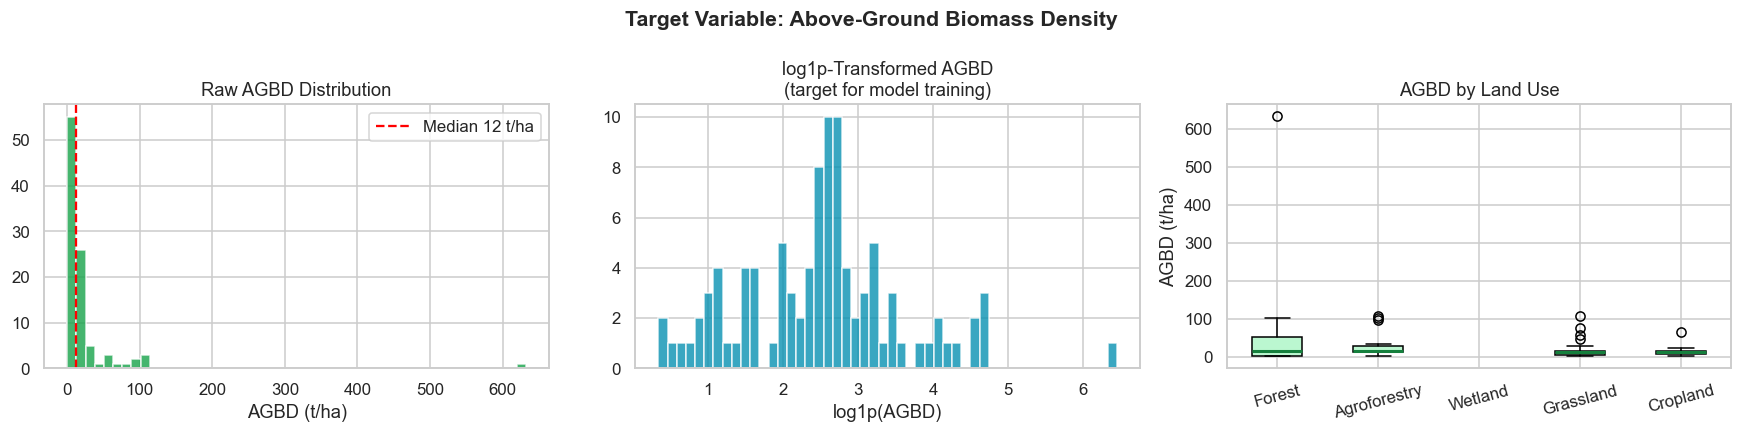

In [41]:
# ── 2.1  Target distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw AGBD
axes[0].hist(df["agbd_tonnes_per_ha"], bins=50, color="#16a34a", alpha=0.8, edgecolor="white")
axes[0].axvline(df["agbd_tonnes_per_ha"].median(), color="red", ls="--",
                label=f'Median {df["agbd_tonnes_per_ha"].median():.0f} t/ha')
axes[0].set_xlabel("AGBD (t/ha)"); axes[0].set_title("Raw AGBD Distribution"); axes[0].legend()

# log1p AGBD
axes[1].hist(np.log1p(df["agbd_tonnes_per_ha"]), bins=50, color="#0891b2", alpha=0.8, edgecolor="white")
axes[1].set_xlabel("log1p(AGBD)"); axes[1].set_title("log1p-Transformed AGBD\n(target for model training)")

# AGBD by land use
land_order = ["Forest", "Agroforestry", "Wetland", "Grassland", "Cropland"]
agbd_by_lu = [df[df["land_use"] == lu]["agbd_tonnes_per_ha"].values for lu in land_order]
bp = axes[2].boxplot(agbd_by_lu, labels=land_order, patch_artist=True,
                     boxprops=dict(facecolor="#bbf7d0"), medianprops=dict(color="#15803d", lw=2))
axes[2].set_ylabel("AGBD (t/ha)"); axes[2].set_title("AGBD by Land Use")
plt.xticks(rotation=15)

plt.suptitle("Target Variable: Above-Ground Biomass Density", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

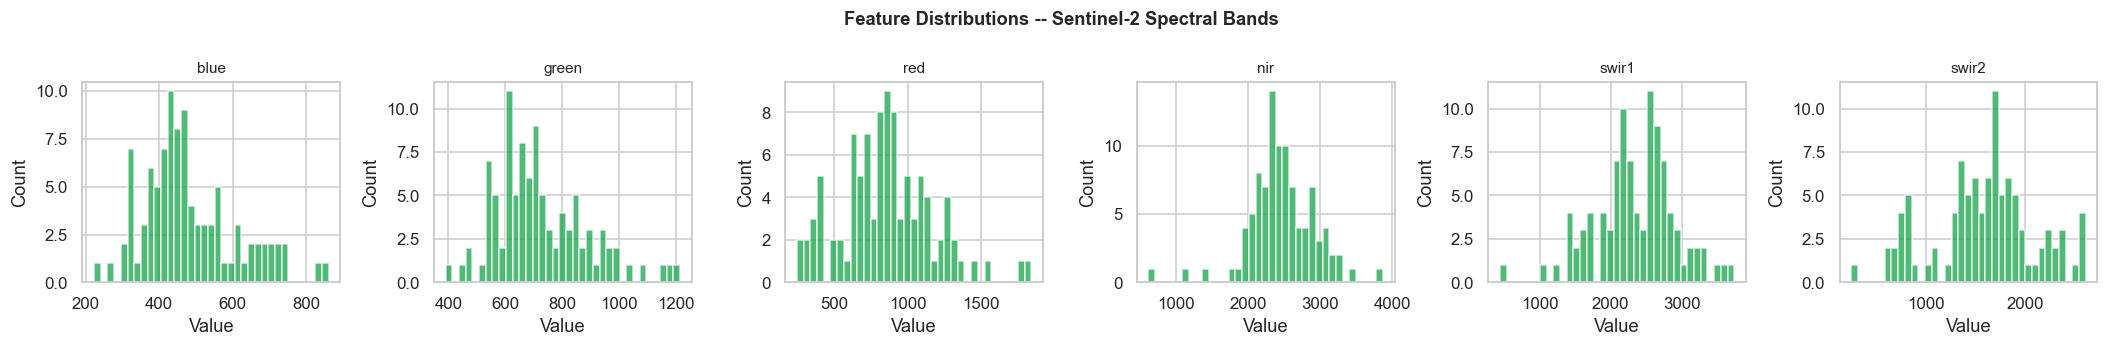

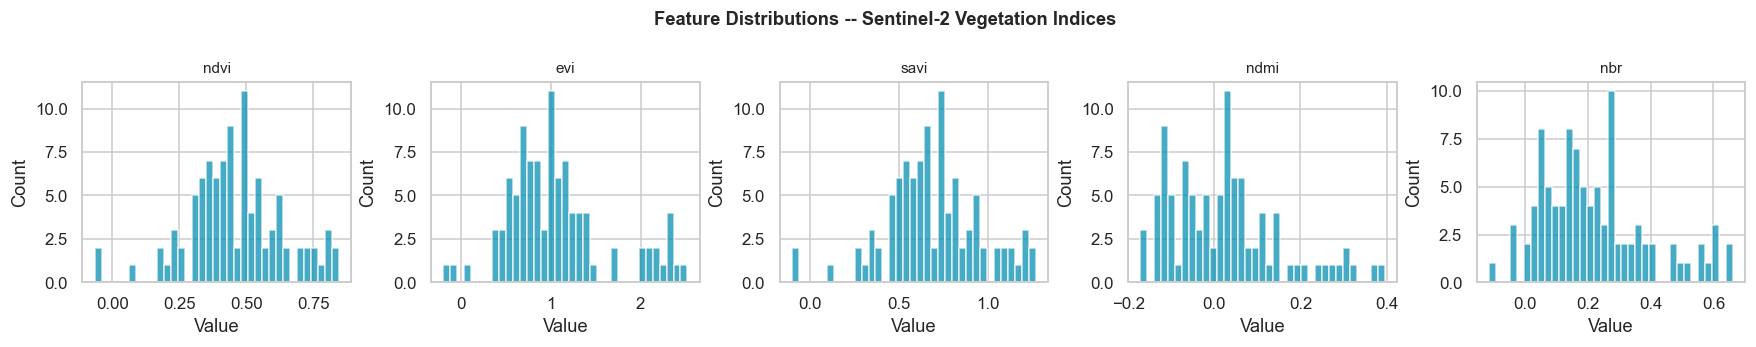

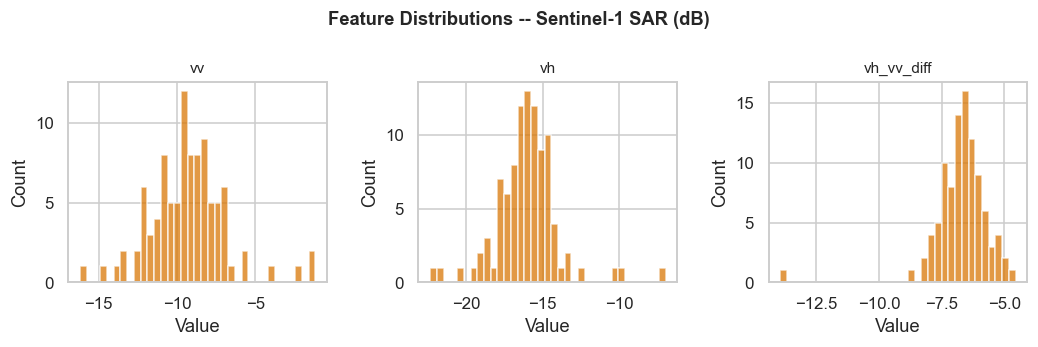

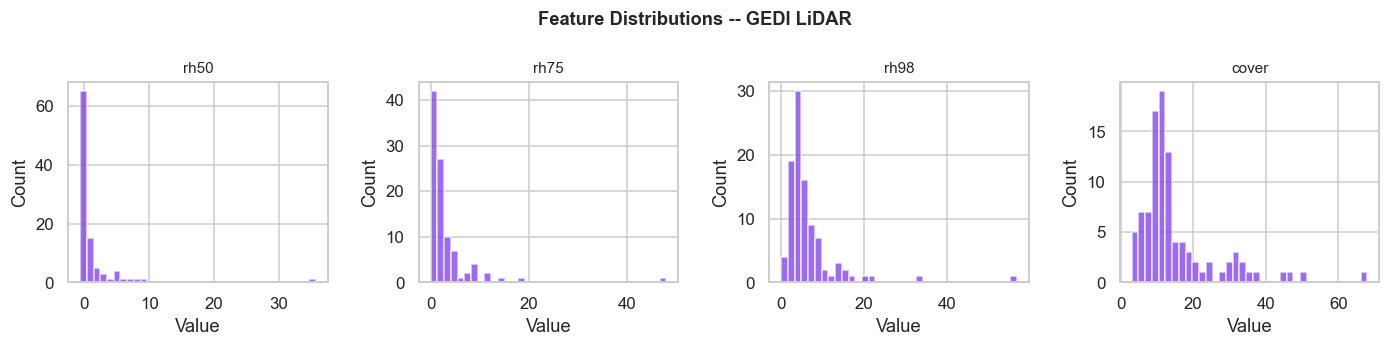

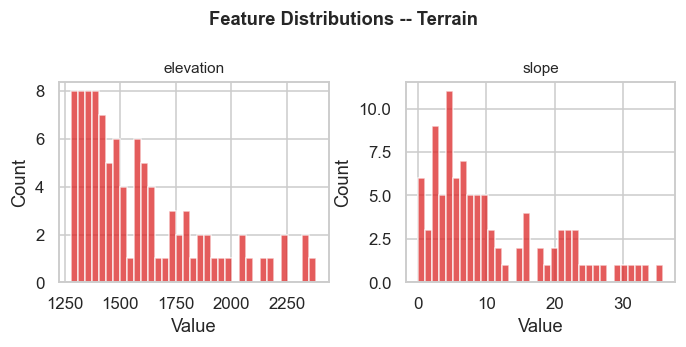

In [42]:
sensor_groups = {
    "Sentinel-2 Spectral Bands": ["blue","green","red","nir","swir1","swir2"],
    "Sentinel-2 Vegetation Indices": ["ndvi","evi","savi","ndmi","nbr"],
    "Sentinel-1 SAR (dB)": ["vv","vh","vh_vv_diff"],
    "GEDI LiDAR": ["rh50","rh75","rh98","cover"],
    "Terrain": ["elevation","slope"],
}
group_colors = ["#16a34a", "#0891b2", "#d97706", "#7c3aed", "#dc2626"]

for (group, feats), color in zip(sensor_groups.items(), group_colors):
    n_feats = len(feats)
    fig, axes = plt.subplots(1, n_feats, figsize=(3.2 * n_feats, 3.2))
    if n_feats == 1:
        axes = [axes]
    for ax, feat in zip(axes, feats):
        ax.hist(df[feat], bins=35, color=color, alpha=0.75, edgecolor="white")
        ax.set_title(feat, fontsize=10)
        ax.set_xlabel("Value")
        ax.set_ylabel("Count")
    fig.suptitle(f"Feature Distributions -- {group}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

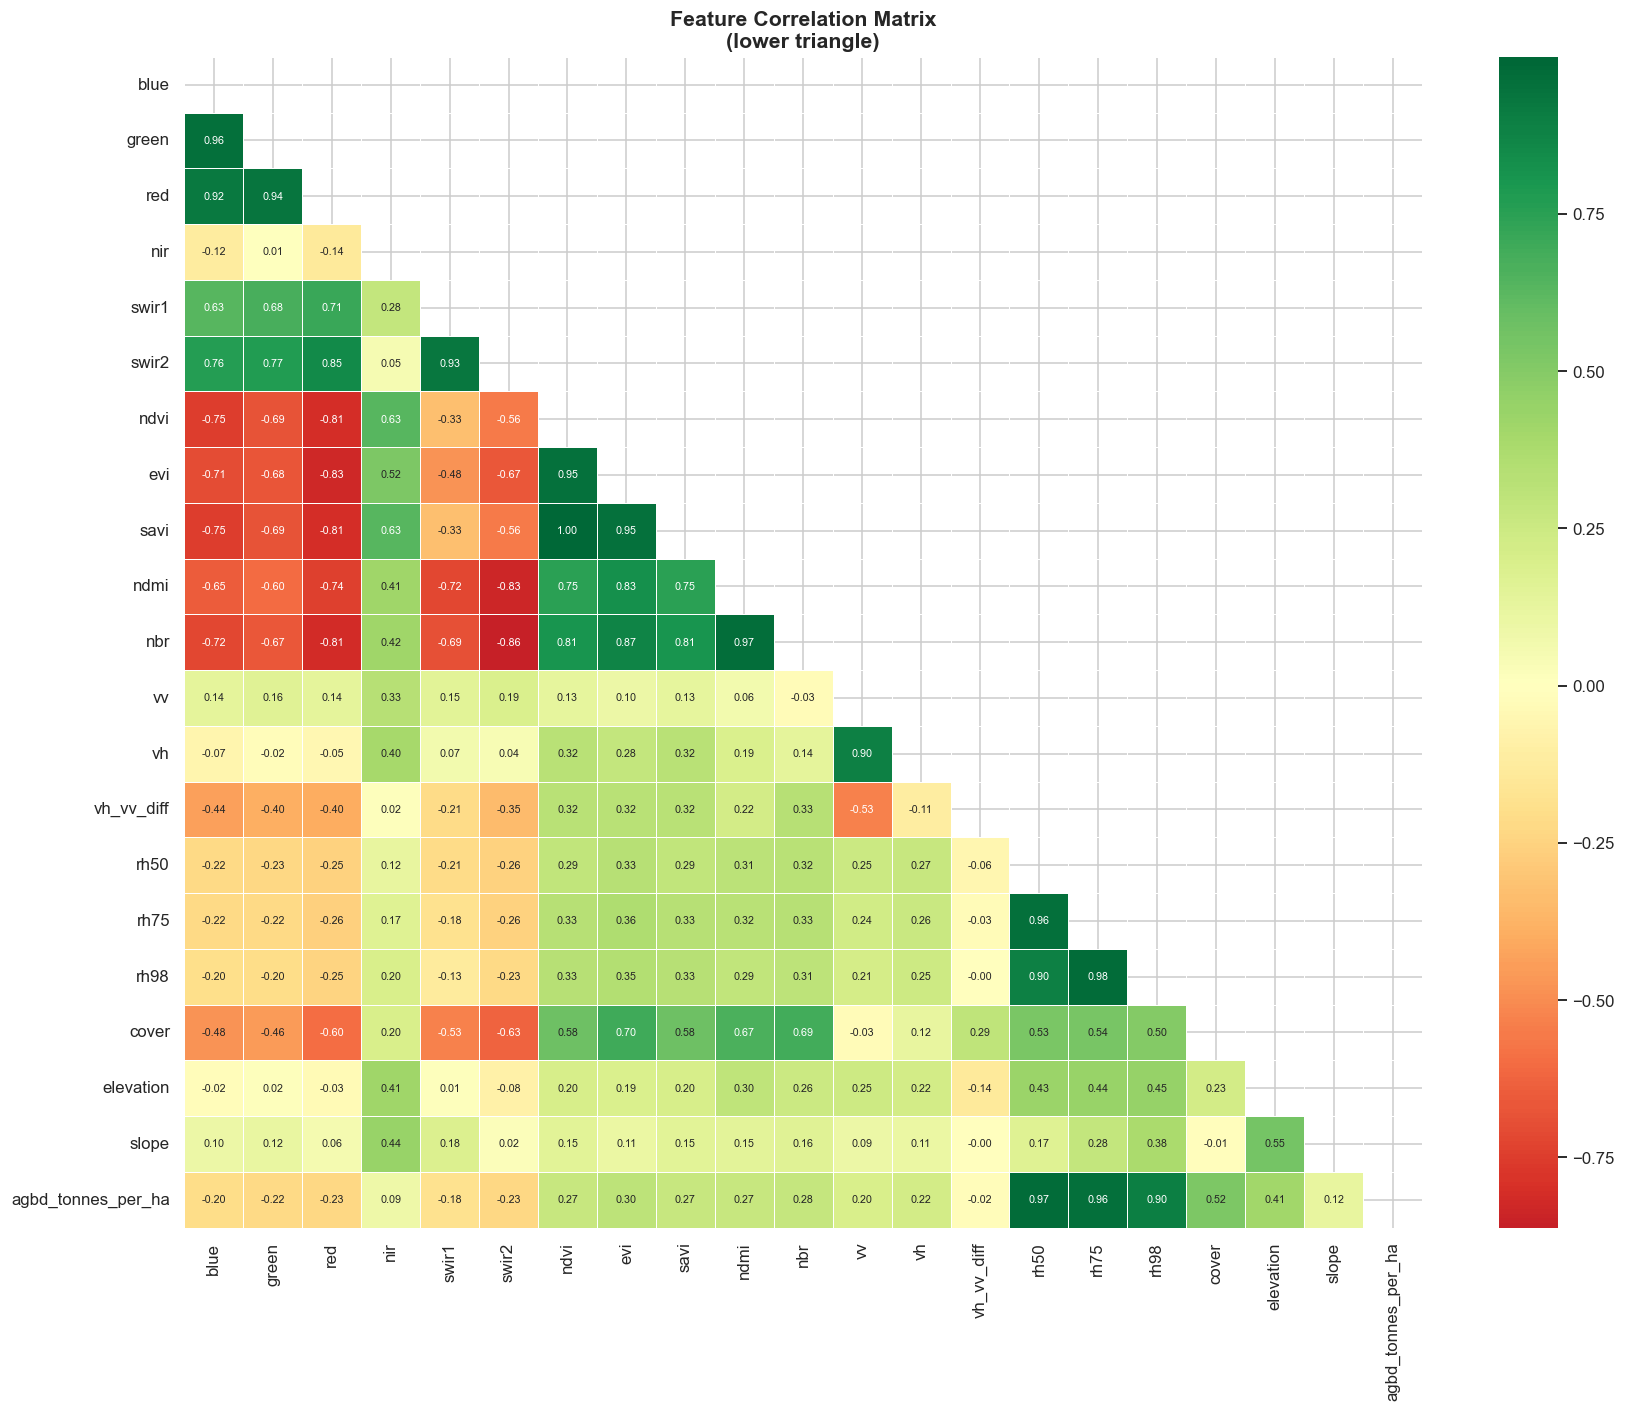

Top correlations with AGBD:
rh50         0.971355
rh75         0.956372
rh98         0.903364
cover        0.522863
elevation    0.406748
evi          0.302406
nbr          0.277867
ndvi         0.269611
savi         0.269574
ndmi         0.267223


In [43]:
# ── 2.3  Correlation heatmap (all features vs AGBD) ──────────────────────────
feature_cols = [
    "blue","green","red","nir","swir1","swir2",
    "ndvi","evi","savi","ndmi","nbr",
    "vv","vh","vh_vv_diff",
    "rh50","rh75","rh98","cover",
    "elevation","slope",
    "agbd_tonnes_per_ha",
]

corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, linewidths=0.4, ax=ax,
    annot_kws={"size": 7},
)
ax.set_title("Feature Correlation Matrix\n(lower triangle)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Print top correlations with AGBD
top_corr = corr["agbd_tonnes_per_ha"].drop("agbd_tonnes_per_ha").abs().sort_values(ascending=False)
print("Top correlations with AGBD:")
print(top_corr.head(10).to_string())

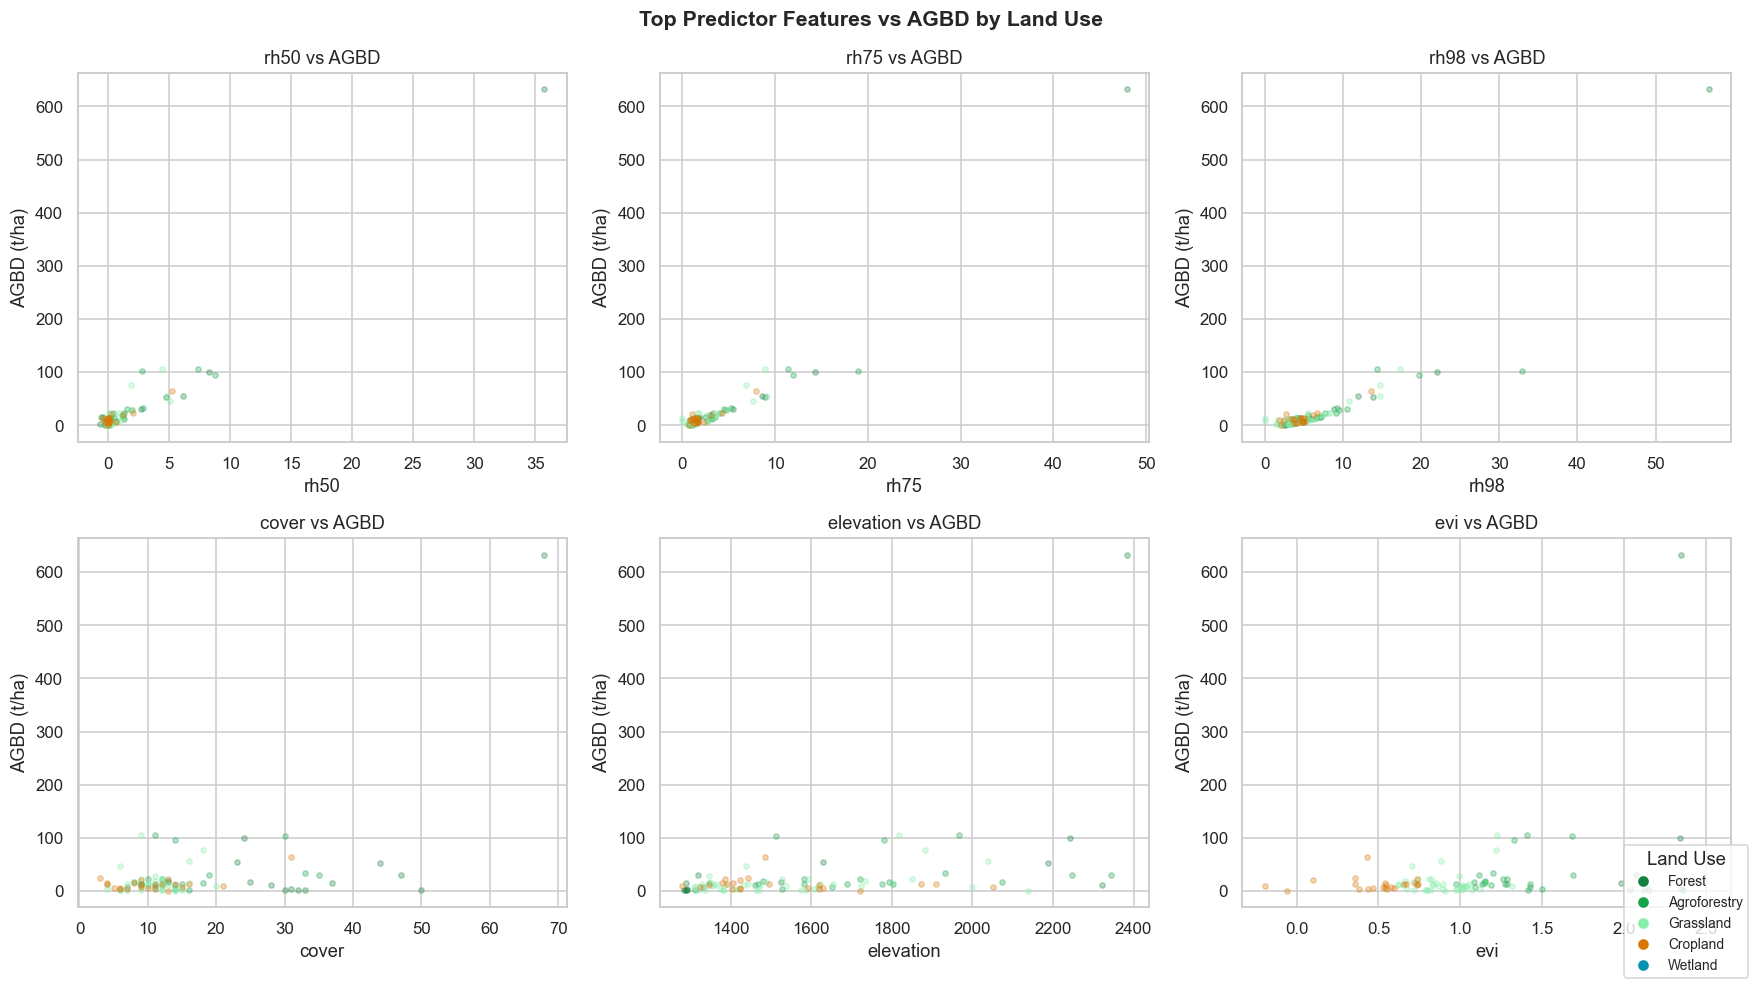

In [44]:
# ── 2.4  Scatter: top predictors vs AGBD ─────────────────────────────────────
top_feats = top_corr.head(6).index.tolist()
palette   = {"Forest":"#15803d","Agroforestry":"#16a34a","Grassland":"#86efac",
             "Cropland":"#d97706","Wetland":"#0891b2"}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feat in zip(axes.flat, top_feats):
    for lu, color in palette.items():
        mask = df["land_use"] == lu
        ax.scatter(df.loc[mask, feat], df.loc[mask, "agbd_tonnes_per_ha"],
                   alpha=0.3, s=12, color=color, label=lu)
    ax.set_xlabel(feat); ax.set_ylabel("AGBD (t/ha)")
    ax.set_title(f"{feat} vs AGBD")

handles = [plt.Line2D([0],[0], marker="o", color="w",
           markerfacecolor=c, markersize=8, label=lu)
           for lu, c in palette.items()]
fig.legend(handles=handles, title="Land Use", loc="lower right", ncol=1, fontsize=9)
plt.suptitle("Top Predictor Features vs AGBD by Land Use", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

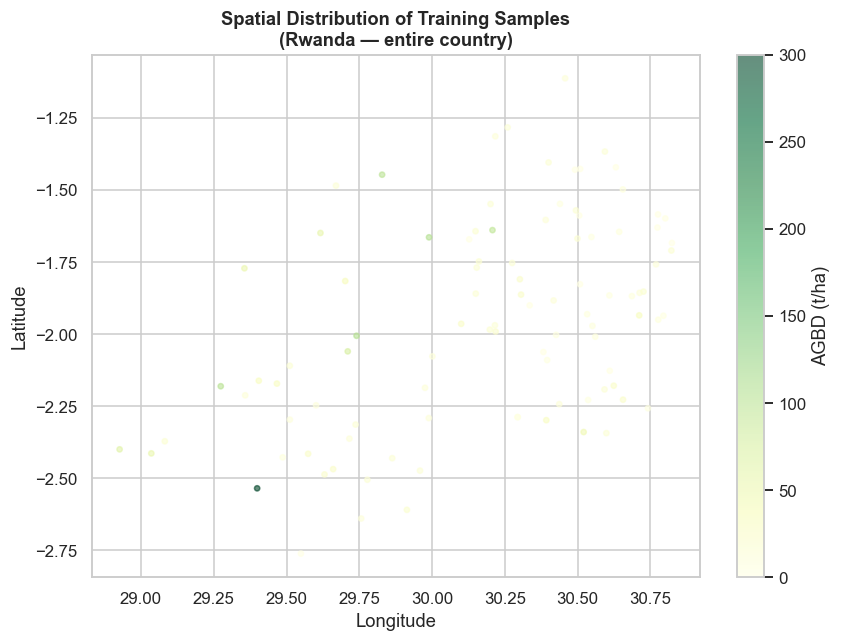

In [ ]:
# ── 2.5  Spatial distribution of sample points ───────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(df["lon"], df["lat"], c=df["agbd_tonnes_per_ha"],
                cmap="YlGn", s=12, alpha=0.6, vmin=0, vmax=300)
plt.colorbar(sc, ax=ax, label="AGBD (t/ha)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Spatial Distribution of Training Samples\n(Rwanda — entire country)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Data Engineering — Feature Preparation & Spatial Cross-Validation

**Key engineering decisions:**
1. **log1p target transform** — biomass is log-normally distributed; training in log-space reduces heteroscedastic error and improves tail predictions  
2. **StandardScaler** — zero-mean, unit-variance scaling required by SVR and CNN; applied per fold to prevent data leakage  
3. **Outlier removal** — samples above the 99.5th percentile excluded (measurement artefacts)  
4. **Spatial block CV** — 0.5° grid blocks assigned as groups for `GroupKFold`; prevents autocorrelation from inflating held-out R² (proposal §3.3.2)

Samples after outlier removal: 97  (cap=377 t/ha)
Spatial blocks : 13  ->  5-fold GroupKFold CV


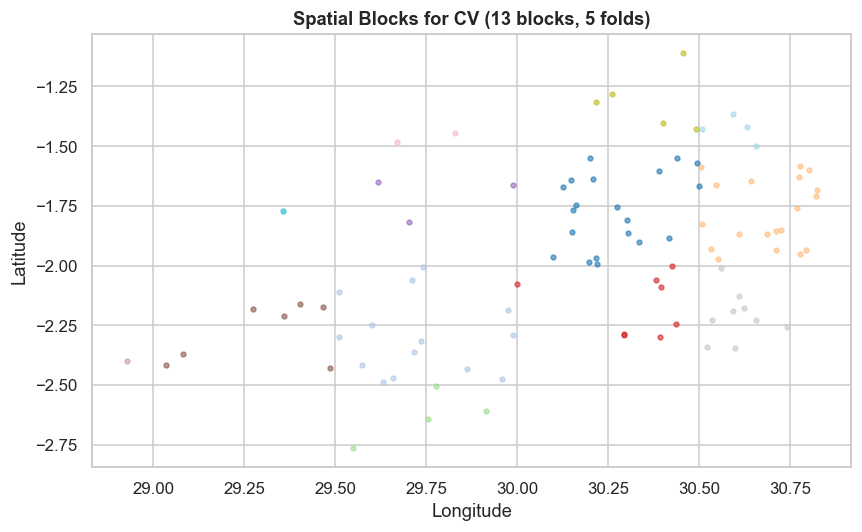

In [46]:
MODEL_FEATURE_COLS = [
    "blue","green","red","nir","swir1","swir2",
    "ndvi","evi","savi","ndmi","nbr",
    "vv","vh","vh_vv_diff",
    "rh50","rh75","rh98","cover",
    "elevation","slope",
]

# Remove outliers (>99.5th percentile)
q995 = df["agbd_tonnes_per_ha"].quantile(0.995)
df_clean = df[df["agbd_tonnes_per_ha"] <= q995].copy().reset_index(drop=True)
print(f"Samples after outlier removal: {len(df_clean):,}  (cap={q995:.0f} t/ha)")

X = df_clean[MODEL_FEATURE_COLS].values
y = df_clean["agbd_tonnes_per_ha"].values
y_log = np.log1p(y)

# Spatial blocks (0.5 degree grid)
BLOCK_SIZE = 0.5
blocks = (
    (df_clean["lat"] // BLOCK_SIZE).astype(str) + "_" +
    (df_clean["lon"] // BLOCK_SIZE).astype(str)
)
n_blocks = blocks.nunique()
N_FOLDS  = min(5, n_blocks)
print(f"Spatial blocks : {n_blocks}  ->  {N_FOLDS}-fold GroupKFold CV")

# Visualise spatial blocks
fig, ax = plt.subplots(figsize=(8, 5))
unique_blocks = blocks.unique()
cmap = plt.cm.get_cmap("tab20", len(unique_blocks))
for i, blk in enumerate(unique_blocks):
    mask = blocks == blk
    ax.scatter(df_clean.loc[mask, "lon"], df_clean.loc[mask, "lat"],
               color=cmap(i), s=10, alpha=0.6)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"Spatial Blocks for CV ({n_blocks} blocks, {N_FOLDS} folds)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Model Architecture & Multi-Model Benchmark

Per proposal Table 4, four model families are benchmarked:

| # | Model | Type | Key hyperparameters |
|---|---|---|---|
| 1 | **Random Forest** | Ensemble (bagging) | 300 trees, unlimited depth, min_samples_leaf=2 |
| 2 | **XGBoost** | Ensemble (boosting) | 600 trees, max_depth=6, lr=0.05, early stopping |
| 3 | **SVR** | Kernel method | RBF kernel, C=10, ε=0.1 |
| 4 | **CNN (MLP)** | Deep learning | 4-layer MLP (128→64→32→1), ReLU, Dropout 0.2, Adam |

All models receive the same **scaled** feature matrix and predict **log1p(AGBD)**.  
Results are converted back via `expm1` for RMSE/MAE reporting in original units (t/ha).

In [47]:
# ── Model factory functions ───────────────────────────────────────────────────

def make_rf():
    return RandomForestRegressor(
        n_estimators=300, max_depth=None, min_samples_leaf=2,
        n_jobs=-1, random_state=42,
    )

def make_xgb(X_val=None, y_val=None):
    if XGB_AVAILABLE:
        m = xgb.XGBRegressor(
            n_estimators=600, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.7,
            reg_alpha=0.1, reg_lambda=1.0,
            n_jobs=-1, random_state=42,
            early_stopping_rounds=30, eval_metric="rmse",
        )
        return m, {"eval_set": [(X_val, y_val)], "verbose": False} if X_val is not None else {}
    else:
        return GradientBoostingRegressor(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, random_state=42,
        ), {}

def make_svr():
    return SVR(kernel="rbf", C=10.0, epsilon=0.1, gamma="scale")

# CNN architecture (MLP for tabular data)
if TORCH_AVAILABLE:
    class BiomassNet(nn.Module):
        def __init__(self, n_in):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(n_in, 128), nn.ReLU(), nn.Dropout(0.2),
                nn.Linear(128,  64), nn.ReLU(), nn.Dropout(0.2),
                nn.Linear( 64,  32), nn.ReLU(),
                nn.Linear( 32,   1),
            )
        def forward(self, x):
            return self.net(x).squeeze(-1)

    def train_cnn(X_tr, y_tr, X_val, y_val, n_epochs=80):
        device = torch.device("cpu")
        model  = BiomassNet(X_tr.shape[1]).to(device)
        opt    = torch.optim.Adam(model.parameters(), lr=1e-3)
        loss_fn = nn.MSELoss()
        Xtr = torch.tensor(X_tr, dtype=torch.float32)
        ytr = torch.tensor(y_tr, dtype=torch.float32)
        Xv  = torch.tensor(X_val, dtype=torch.float32)
        yv  = torch.tensor(y_val, dtype=torch.float32)
        best_loss, best_state = float("inf"), None
        for _ in range(n_epochs):
            model.train(); opt.zero_grad()
            loss = loss_fn(model(Xtr), ytr); loss.backward(); opt.step()
            model.eval()
            with torch.no_grad():
                vl = loss_fn(model(Xv), yv).item()
            if vl < best_loss:
                best_loss  = vl
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
        model.load_state_dict(best_state)
        return model

    def predict_cnn(model, X):
        with torch.no_grad():
            return model(torch.tensor(X, dtype=torch.float32)).numpy()

print("Model factory functions defined ✅")

# Print CNN architecture summary if available
if TORCH_AVAILABLE:
    net = BiomassNet(len(MODEL_FEATURE_COLS))
    print("\nCNN (BiomassNet) architecture:")
    print(net)

Model factory functions defined ✅

CNN (BiomassNet) architecture:
BiomassNet(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [48]:
# ── Spatial block CV — benchmark all four models ─────────────────────────────
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=N_FOLDS)

def run_cv(name, fold_fn):
    """Run spatial block CV for one model; return per-fold and mean metrics."""
    fold_rows = []
    for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y_log, groups=blocks)):
        sc = StandardScaler()
        X_tr  = sc.fit_transform(X[tr_idx])
        X_val = sc.transform(X[val_idx])
        y_tr, y_val_orig = y_log[tr_idx], y[val_idx]

        y_pred_log = fold_fn(X_tr, y_tr, X_val, y_log[val_idx])
        y_pred     = np.expm1(y_pred_log)

        fold_rows.append({
            "fold": fold + 1,
            "r2":   r2_score(y_val_orig, y_pred),
            "mae":  mean_absolute_error(y_val_orig, y_pred),
            "rmse": np.sqrt(mean_squared_error(y_val_orig, y_pred)),
            "bias": float(np.mean(y_pred - y_val_orig)),
        })
    means = {k: float(np.mean([f[k] for f in fold_rows])) for k in ("r2","mae","rmse","bias")}
    stds  = {k: float(np.std ([f[k] for f in fold_rows])) for k in ("r2","rmse")}
    print(f"  {name:10s}  R²={means['r2']:.4f}±{stds['r2']:.4f}  "
          f"RMSE={means['rmse']:.1f}±{stds['rmse']:.1f}  "
          f"MAE={means['mae']:.1f}  Bias={means['bias']:+.1f} t/ha")
    return fold_rows, means, stds

benchmark = {}   # name → (fold_rows, means, stds)

print("── Spatial block CV benchmark ──────────────────────────────────────")
print(f"   {N_FOLDS} folds, {len(df_clean):,} samples, {len(MODEL_FEATURE_COLS)} features\n")

# 1. Random Forest
def rf_fold(X_tr, y_tr, X_val, _):
    m = make_rf(); m.fit(X_tr, y_tr); return m.predict(X_val)
benchmark["Random Forest"] = run_cv("Random Forest", rf_fold)

# 2. XGBoost
def xgb_fold(X_tr, y_tr, X_val, y_val_log):
    if XGB_AVAILABLE:
        m = xgb.XGBRegressor(
            n_estimators=600, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.7, n_jobs=-1, random_state=42,
            early_stopping_rounds=30, eval_metric="rmse",
        )
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val_log)], verbose=False)
    else:
        m = GradientBoostingRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                      subsample=0.8, random_state=42)
        m.fit(X_tr, y_tr)
    return m.predict(X_val)
benchmark["XGBoost"] = run_cv("XGBoost", xgb_fold)

# 3. SVR
def svr_fold(X_tr, y_tr, X_val, _):
    m = make_svr(); m.fit(X_tr, y_tr); return m.predict(X_val)
benchmark["SVR"] = run_cv("SVR", svr_fold)

# 4. CNN/MLP
if TORCH_AVAILABLE:
    def cnn_fold(X_tr, y_tr, X_val, y_val_log):
        m = train_cnn(X_tr, y_tr, X_val, y_val_log)
        return predict_cnn(m, X_val)
    benchmark["CNN (MLP)"] = run_cv("CNN (MLP)", cnn_fold)
else:
    print("  CNN (MLP)   — skipped (PyTorch not installed)")

print("\n✅ Benchmark complete")

── Spatial block CV benchmark ──────────────────────────────────────
   5 folds, 97 samples, 20 features

  Random Forest  R²=0.8490±0.0513  RMSE=7.7±3.6  MAE=5.9  Bias=-1.8 t/ha
  XGBoost     R²=0.7002±0.0860  RMSE=10.7±4.4  MAE=7.2  Bias=-3.1 t/ha
  SVR         R²=0.3456±0.1895  RMSE=15.7±6.3  MAE=9.8  Bias=-4.9 t/ha
  CNN (MLP)   R²=-15.0500±21.2887  RMSE=71.4±52.5  MAE=26.7  Bias=+12.8 t/ha

✅ Benchmark complete


## 5. Initial Performance Metrics

In [49]:
# ── 5.1  Summary metrics table ───────────────────────────────────────────────
rows = []
for name, (fold_rows, means, stds) in benchmark.items():
    rows.append({
        "Model": name,
        "CV R²": f"{means['r2']:.4f} ± {stds['r2']:.4f}",
        "CV RMSE (t/ha)": f"{means['rmse']:.1f} ± {stds['rmse']:.1f}",
        "CV MAE (t/ha)": f"{means['mae']:.1f}",
        "Bias (t/ha)": f"{means['bias']:+.1f}",
    })

metrics_df = pd.DataFrame(rows)
best_name  = min(benchmark, key=lambda k: benchmark[k][1]["rmse"])
print(f"{'='*60}")
print(f"BENCHMARK RESULTS — Spatial Block CV ({N_FOLDS} folds)")
print(f"{'='*60}")
print(metrics_df.to_string(index=False))
print(f"\n✅ Best model by RMSE: {best_name}")
metrics_df

BENCHMARK RESULTS — Spatial Block CV (5 folds)
        Model              CV R² CV RMSE (t/ha) CV MAE (t/ha) Bias (t/ha)
Random Forest    0.8490 ± 0.0513      7.7 ± 3.6           5.9        -1.8
      XGBoost    0.7002 ± 0.0860     10.7 ± 4.4           7.2        -3.1
          SVR    0.3456 ± 0.1895     15.7 ± 6.3           9.8        -4.9
    CNN (MLP) -15.0500 ± 21.2887    71.4 ± 52.5          26.7       +12.8

✅ Best model by RMSE: Random Forest


,Model,CV R²,CV RMSE (t/ha),CV MAE (t/ha),Bias (t/ha)
0,Random Forest,0.8490 ± 0.0513,7.7 ± 3.6,5.9,-1.8
1,XGBoost,0.7002 ± 0.0860,10.7 ± 4.4,7.2,-3.1
2,SVR,0.3456 ± 0.1895,15.7 ± 6.3,9.8,-4.9
3,CNN (MLP),-15.0500 ± 21.2887,71.4 ± 52.5,26.7,+12.8


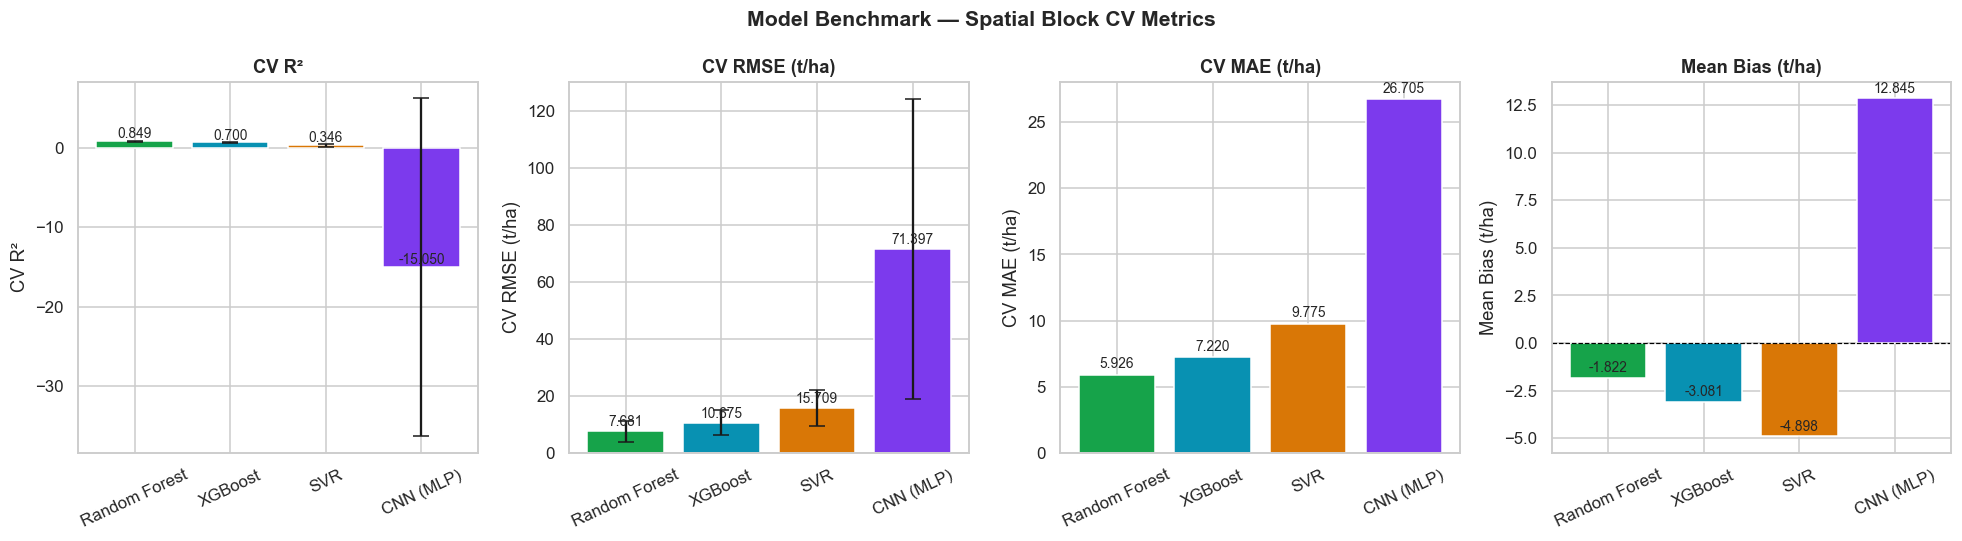

In [50]:
# ── 5.2  Metric comparison bar charts ────────────────────────────────────────
model_names = list(benchmark.keys())
means_list  = [benchmark[n][1] for n in model_names]
stds_list   = [benchmark[n][2] for n in model_names]
bar_colors  = ["#16a34a", "#0891b2", "#d97706", "#7c3aed"][:len(model_names)]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

metrics_plot = [
    ("r2",   "CV R²",        stds_list, True),
    ("rmse", "CV RMSE (t/ha)", stds_list, False),
    ("mae",  "CV MAE (t/ha)", None, False),
    ("bias", "Mean Bias (t/ha)", None, False),
]

for ax, (key, label, stds, higher_better) in zip(axes, metrics_plot):
    vals  = [m[key]    for m in means_list]
    errs  = [s.get(key, 0) for s in stds_list] if stds else None
    bars  = ax.bar(model_names, vals, color=bar_colors,
                   yerr=errs, capsize=5, error_kw={"elinewidth": 1.5})
    ax.set_title(label, fontweight="bold")
    ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=25)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (max(vals)*0.01),
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    if key == "bias":
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

plt.suptitle("Model Benchmark — Spatial Block CV Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

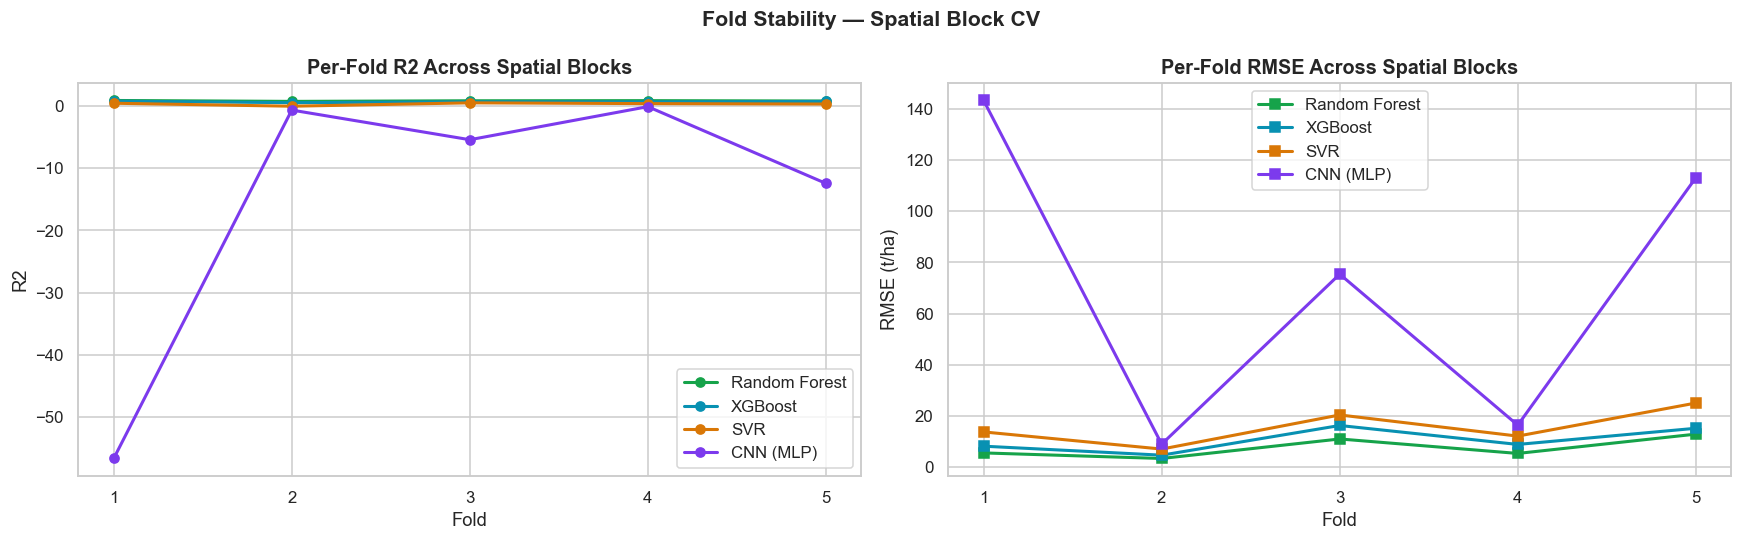

In [51]:
# Per-fold R2 stability
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
bar_colors = ["#16a34a", "#0891b2", "#d97706", "#7c3aed"][:len(benchmark)]

for i, (name, (fold_rows, _, _)) in enumerate(benchmark.items()):
    fold_r2 = [f["r2"] for f in fold_rows]
    axes[0].plot(range(1, len(fold_r2)+1), fold_r2,
                 marker="o", linewidth=2, label=name, color=bar_colors[i])

axes[0].set_xlabel("Fold"); axes[0].set_ylabel("R2")
axes[0].set_title("Per-Fold R2 Across Spatial Blocks", fontsize=13, fontweight="bold")
axes[0].legend(); axes[0].set_xticks(range(1, N_FOLDS+1))

for i, (name, (fold_rows, _, _)) in enumerate(benchmark.items()):
    fold_rmse = [f["rmse"] for f in fold_rows]
    axes[1].plot(range(1, len(fold_rmse)+1), fold_rmse,
                 marker="s", linewidth=2, label=name, color=bar_colors[i])

axes[1].set_xlabel("Fold"); axes[1].set_ylabel("RMSE (t/ha)")
axes[1].set_title("Per-Fold RMSE Across Spatial Blocks", fontsize=13, fontweight="bold")
axes[1].legend(); axes[1].set_xticks(range(1, N_FOLDS+1))

plt.suptitle("Fold Stability — Spatial Block CV", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [52]:
# ── Train final model on full dataset ────────────────────────────────────────
final_scaler = StandardScaler()
X_all_s = final_scaler.fit_transform(X)

print(f"Training final {best_name} on {len(X_all_s):,} samples …")

if best_name == "Random Forest":
    final_model = make_rf()
    final_model.fit(X_all_s, y_log)
    is_torch = False
elif best_name == "SVR":
    final_model = make_svr()
    final_model.fit(X_all_s, y_log)
    is_torch = False
elif best_name == "CNN (MLP)" and TORCH_AVAILABLE:
    final_model = train_cnn(X_all_s, y_log, X_all_s, y_log, n_epochs=100)
    is_torch = True
else:
    # XGBoost / GBR
    if XGB_AVAILABLE:
        final_model = xgb.XGBRegressor(
            n_estimators=600, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.7, n_jobs=-1, random_state=42,
        )
        final_model.fit(X_all_s, y_log)
    else:
        final_model = GradientBoostingRegressor(
            n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42)
        final_model.fit(X_all_s, y_log)
    is_torch = False

# Predictions on all data (in-sample, upper bound)
if is_torch:
    y_pred_log_all = predict_cnn(final_model, X_all_s)
else:
    y_pred_log_all = final_model.predict(X_all_s)
y_pred_all = np.expm1(y_pred_log_all)

train_r2   = r2_score(y, y_pred_all)
train_rmse = np.sqrt(mean_squared_error(y, y_pred_all))
train_mae  = mean_absolute_error(y, y_pred_all)
cv_r2      = benchmark[best_name][1]["r2"]
cv_rmse    = benchmark[best_name][1]["rmse"]

print(f"\nFinal model ({best_name})")
print(f"  Full-data train R² : {train_r2:.4f}  RMSE: {train_rmse:.1f} t/ha")
print(f"  Spatial CV   R²    : {cv_r2:.4f}  RMSE: {cv_rmse:.1f} t/ha  ← honest estimate")

Training final Random Forest on 97 samples …

Final model (Random Forest)
  Full-data train R² : 0.9759  RMSE: 3.7 t/ha
  Spatial CV   R²    : 0.8490  RMSE: 7.7 t/ha  ← honest estimate


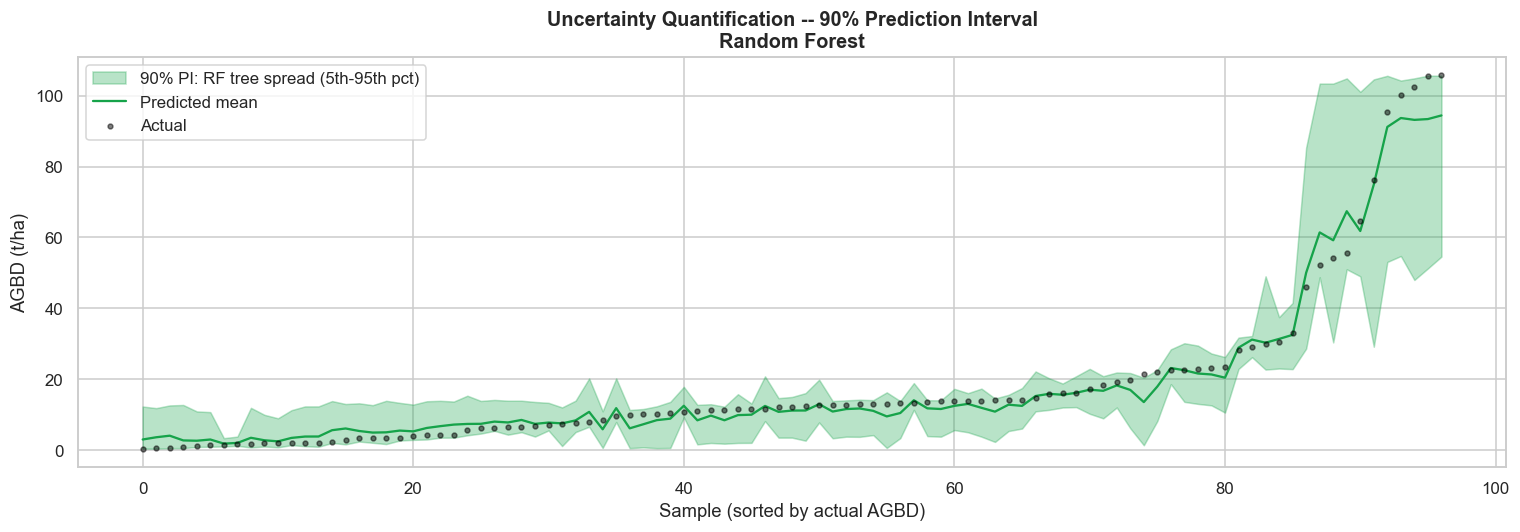

Sample size     : 97
90% PI coverage : 96.9%  (target >= 90%)
Average PI width: 16.5 t/ha


In [53]:
# Uncertainty quantification
# RF: spread across individual trees gives prediction intervals
# Others: +/-1.645 sigma using CV RMSE as sigma proxy (90% PI)

SAMPLE_N = min(500, len(X_all_s))
SAMPLE_IDX = np.random.choice(len(X_all_s), SAMPLE_N, replace=False)
X_sample   = X_all_s[SAMPLE_IDX]
y_sample   = y[SAMPLE_IDX]

if best_name == "Random Forest" and hasattr(final_model, "estimators_"):
    tree_preds = np.array([t.predict(X_sample) for t in final_model.estimators_])
    tree_preds = np.expm1(tree_preds)
    y_lower    = np.percentile(tree_preds, 5, axis=0)
    y_upper    = np.percentile(tree_preds, 95, axis=0)
    y_mean_s   = np.mean(tree_preds, axis=0)
    pi_label   = "RF tree spread (5th-95th pct)"
else:
    if is_torch:
        y_mean_s = np.expm1(predict_cnn(final_model, X_sample))
    else:
        y_mean_s = np.expm1(final_model.predict(X_sample))
    y_lower  = np.maximum(0, y_mean_s - 1.645 * cv_rmse)
    y_upper  = y_mean_s + 1.645 * cv_rmse
    pi_label = f"+/-1.645 sigma  (sigma = CV RMSE = {cv_rmse:.1f})"

sort_idx = np.argsort(y_sample)
fig, ax  = plt.subplots(figsize=(14, 5))
ax.fill_between(range(SAMPLE_N), y_lower[sort_idx], y_upper[sort_idx],
                alpha=0.3, color="#16a34a", label=f"90% PI: {pi_label}")
ax.plot(y_mean_s[sort_idx], color="#16a34a", lw=1.5, label="Predicted mean")
ax.scatter(range(SAMPLE_N), y_sample[sort_idx], s=10, color="black", alpha=0.5, zorder=3, label="Actual")
ax.set_xlabel("Sample (sorted by actual AGBD)")
ax.set_ylabel("AGBD (t/ha)")
ax.set_title(f"Uncertainty Quantification -- 90% Prediction Interval\n{best_name}", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

coverage = np.mean((y_sample[sort_idx] >= y_lower[sort_idx]) & (y_sample[sort_idx] <= y_upper[sort_idx]))
avg_width = np.mean(y_upper - y_lower)
print(f"Sample size     : {SAMPLE_N}")
print(f"90% PI coverage : {coverage*100:.1f}%  (target >= 90%)")
print(f"Average PI width: {avg_width:.1f} t/ha")

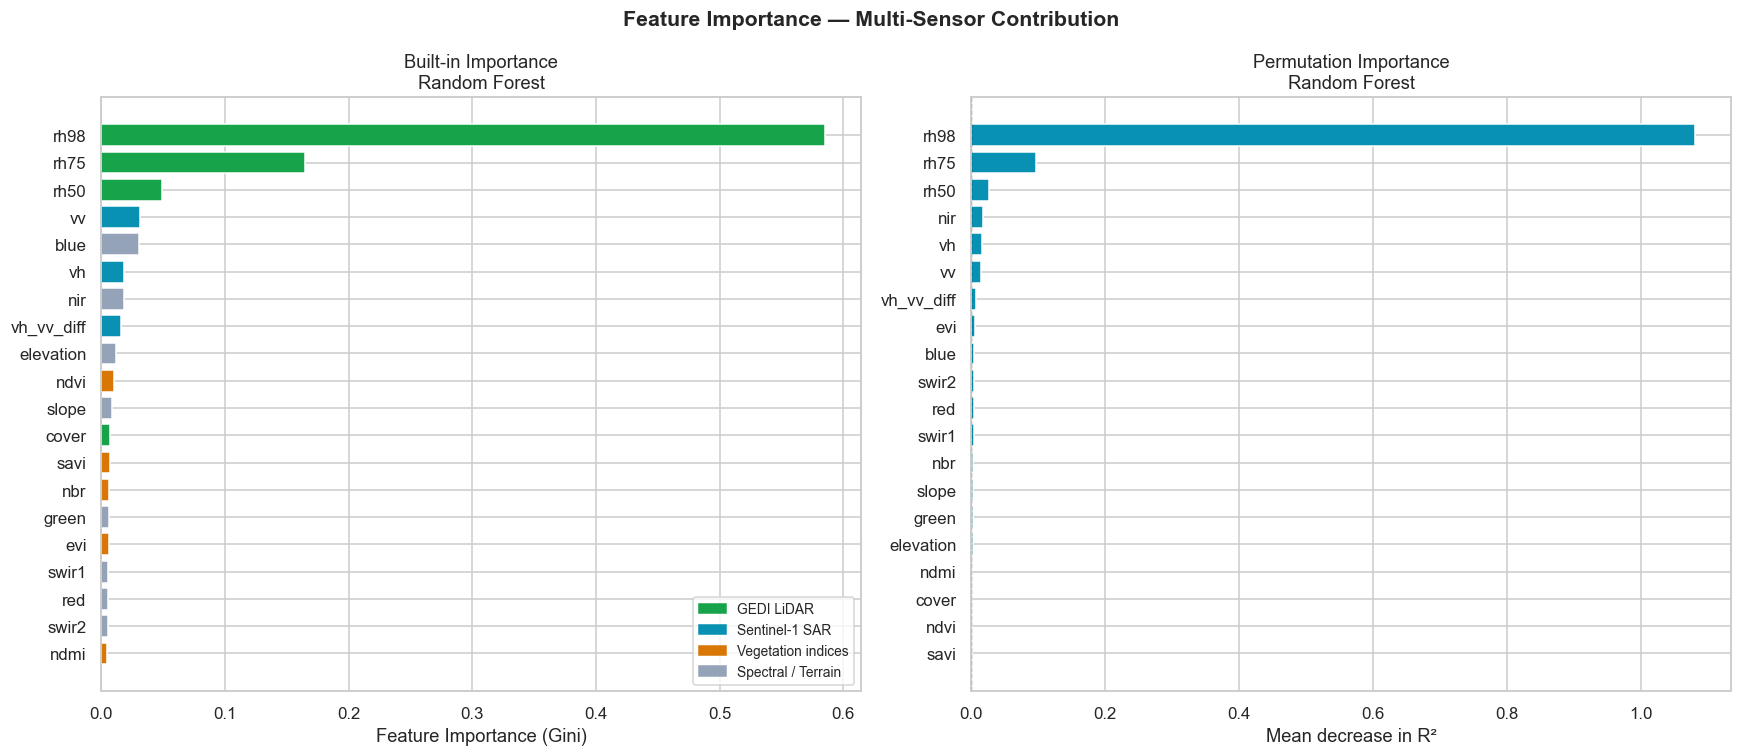


Top 5 features by permutation importance:
rh98    1.080990
rh75    0.097104
rh50    0.026222
nir     0.017069
vh      0.015440


In [54]:
# ── 7.1  Built-in feature importance (tree models only) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

if hasattr(final_model, "feature_importances_"):
    imp  = pd.Series(final_model.feature_importances_, index=MODEL_FEATURE_COLS).sort_values()
    colors_imp = ["#16a34a" if f in ["rh98","rh75","rh50","cover"] else
                  "#0891b2" if f in ["vv","vh","vh_vv_diff"] else
                  "#d97706" if f in ["ndvi","evi","savi","ndmi","nbr"] else
                  "#94a3b8"
                  for f in imp.index]
    axes[0].barh(imp.index, imp.values, color=colors_imp)
    axes[0].set_xlabel("Feature Importance (Gini)")
    axes[0].set_title(f"Built-in Importance\n{best_name}")

    # Legend
    from matplotlib.patches import Patch
    legend_els = [
        Patch(color="#16a34a", label="GEDI LiDAR"),
        Patch(color="#0891b2", label="Sentinel-1 SAR"),
        Patch(color="#d97706", label="Vegetation indices"),
        Patch(color="#94a3b8", label="Spectral / Terrain"),
    ]
    axes[0].legend(handles=legend_els, loc="lower right", fontsize=9)
else:
    axes[0].text(0.5, 0.5, "Not available\n(SVR / CNN)", ha="center", va="center",
                 transform=axes[0].transAxes, fontsize=12)
    axes[0].set_title("Built-in Importance")

# ── 7.2  Permutation importance ────────────────────────────────────────────────
# Use a random 20% hold-out for speed
holdout = np.random.choice(len(X_all_s), int(0.2*len(X_all_s)), replace=False)
X_ho, y_ho = X_all_s[holdout], y[holdout]

if is_torch:
    # Manual permutation for CNN
    base_rmse = np.sqrt(mean_squared_error(y_ho, np.expm1(predict_cnn(final_model, X_ho))))
    perm_scores = []
    for fi in range(X_ho.shape[1]):
        X_perm = X_ho.copy(); np.random.shuffle(X_perm[:, fi])
        rmse_perm = np.sqrt(mean_squared_error(y_ho, np.expm1(predict_cnn(final_model, X_perm))))
        perm_scores.append(rmse_perm - base_rmse)
    perm_ser = pd.Series(perm_scores, index=MODEL_FEATURE_COLS).sort_values()
else:
    perm = permutation_importance(
        final_model, X_ho, np.log1p(y_ho),   # log-space consistent with model
        n_repeats=8, random_state=42, scoring="r2",
    )
    perm_ser = pd.Series(perm.importances_mean, index=MODEL_FEATURE_COLS).sort_values()

axes[1].barh(perm_ser.index, perm_ser.values, color="#0891b2")
xlabel = "Δ RMSE (t/ha)" if is_torch else "Mean decrease in R²"
axes[1].set_xlabel(xlabel)
axes[1].set_title(f"Permutation Importance\n{best_name}")
axes[1].axvline(0, color="black", lw=0.8, ls="--")

plt.suptitle("Feature Importance — Multi-Sensor Contribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nTop 5 features by permutation importance:")
print(perm_ser.abs().sort_values(ascending=False).head(5).to_string())

## 8. Export — Save Model Package